


# ============================================================
# MODEL / EXPERIMENT CONFIGURATION
baseline pipeline  6(1.5 h) Model + wevelet
# ============================================================
freq="15min"

train_stations = [1, 2, 4, 6]

val_stations = [3]

test_stations = [5]

TARGET_FEATURE = "scd41_co2"

SEQ_LENGTH = 48

OUTPUT_LENGTH = 6

BATCH_SIZE = 32

d_model=64

nhead=4

num_layers=2

dropout=0.1

lr=0.0005

EPOCHS = 10

J=3

Q=8




## Import Libraries and GPU Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Speed optimization
torch.backends.cudnn.benchmark = True



Using device: cpu


In [2]:
from torch.utils.data import Dataset

## Device Setup

## Load and Sort Dataset

In [3]:
df = pd.read_csv("../../data/indoorAir2.csv")

#df = pd.read_csv("../data/indoorAir2.csv")
# Convert timestamp once
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort efficiently
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)        
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cyclic Time Feature Engineering

In [4]:
# Extract time information only once
hour = (df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60)
dayofweek = df["timestamp"].dt.dayofweek

# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Day of week cyclic encoding
df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)

# Weekend feature
df["is_weekend"] = (dayofweek.isin([5, 6]).astype(int))

# Final feature dataframe
feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "hour_sin",
        "hour_cos",
        "dayofweek_sin",
        "dayofweek_cos",
        "is_weekend",
        "station_id",
    ]
].copy()

print("Feature Data Shape:", feature_df.shape)
feature_df.head()

Feature Data Shape: (1924653, 14)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,-0.962455,-0.271440,0.974928,-0.222521,0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,-0.963630,-0.267238,0.974928,-0.222521,0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,-0.964787,-0.263031,0.974928,-0.222521,0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,-0.967046,-0.254602,0.974928,-0.222521,0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,-0.968148,-0.250380,0.974928,-0.222521,0,1


## Train Validation Test Split

In [5]:
# Define station groups
train_stations = [1, 2, 4, 6]
val_stations = [3]
test_stations = [5]

# Create train validation and test datasets
train_df = feature_df[feature_df["station_id"].isin(train_stations)].copy()
val_df = feature_df[feature_df["station_id"].isin(val_stations)].copy()
test_df = feature_df[feature_df["station_id"].isin(test_stations)].copy()

# Print dataset shapes
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

# Verify station distribution
print("\nTrain Stations:", train_df["station_id"].unique())
print("Validation Stations:", val_df["station_id"].unique())
print("Test Stations:", test_df["station_id"].unique())

Train Shape      : (1310556, 14)
Validation Shape : (361836, 14)
Test Shape       : (252261, 14)

Train Stations: [1 2 4 6]
Validation Stations: [3]
Test Stations: [5]


## Remove large timstamp gaps

In [6]:
def remove_large_gaps(data, threshold_hours=3):
    data = data.copy()

    # Ensure timestamp is datetime index
    if "timestamp" in data.columns:
        data["timestamp"] = pd.to_datetime(data["timestamp"])
        data = data.sort_values("timestamp").set_index("timestamp")
    else:
        data.index = pd.to_datetime(data.index)
        data = data.sort_index()

    # Calculate time differences
    time_diff = data.index.to_series().diff()
    gap_threshold = pd.Timedelta(hours=threshold_hours)

    # Identify large gaps
    large_gaps = time_diff > gap_threshold
    print("Large gaps found:",large_gaps.sum())

    # Remove rows after large gaps
    cleaned_data = data.loc[~large_gaps]
    return cleaned_data


# Apply gap removal
train_df = remove_large_gaps(train_df)
val_df = remove_large_gaps(val_df)
test_df = remove_large_gaps(test_df)

# Print final shapes
print("\nAfter Removing Large Gaps")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

Large gaps found: 10
Large gaps found: 14
Large gaps found: 9

After Removing Large Gaps
Train Shape      : (1310546, 13)
Validation Shape : (361822, 13)
Test Shape       : (252252, 13)


## Resample each station separately

In [7]:
def resample_station_data(data, freq="15min"):

    station_data_list = []
    # Process each station separately
    for station in data["station_id"].unique():
        # Select one station
        station_df = data[
            data["station_id"] == station
        ].copy()
        # Sort by timestamp index
        station_df = station_df.sort_index()
        # Resample
        station_df = station_df.resample(freq).mean()
        # Restore station ID
        station_df["station_id"] = station
        # Store result
        station_data_list.append(station_df)

    # Combine all stations
    final_df = pd.concat(station_data_list)
    return final_df

# Apply resampling
train_df = resample_station_data(train_df)
val_df = resample_station_data(val_df)
test_df = resample_station_data(test_df)

# Print shapes after resampling
print("After Resampling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

After Resampling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Handling missing values

In [8]:
def handle_missing_values(data):
    # Time-based interpolation
    data = data.interpolate(method="time")
    
    # Forward fill remaining missing values
    data = data.ffill()
    
    # Backward fill remaining missing values
    data = data.bfill()
    
    # Drop any remaining NaN values
    data = data.dropna()   
    return data
    
# Apply missing value handling
train_df = handle_missing_values(train_df)
val_df = handle_missing_values(val_df)
test_df = handle_missing_values(test_df)

# Check missing values
print("Train Missing Values      :", train_df.isna().sum().sum())
print("Validation Missing Values :", val_df.isna().sum().sum())
print("Test Missing Values       :", test_df.isna().sum().sum())

# Final dataset shapes
print("\nAfter Missing Value Handling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

Train Missing Values      : 0
Validation Missing Values : 0
Test Missing Values       : 0

After Missing Value Handling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Feature Scaling and Normalization

In [9]:
feature_columns = [

    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",

    "hour_sin",
    "hour_cos",

    "dayofweek_sin",
    "dayofweek_cos",

    "is_weekend"
]

# Keep only existing columns
feature_columns = [
    col for col in feature_columns
    if col in train_df.columns
]

# Select features
train_features = train_df[feature_columns]
val_features = val_df[feature_columns]
test_features = test_df[feature_columns]

# Initialize scaler
scaler = MinMaxScaler()

# Fit only on training data
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)

# Print scaled data shapes
print("Train Scaled Shape      :", train_scaled.shape)
print("Validation Scaled Shape :", val_scaled.shape)
print("Test Scaled Shape       :", test_scaled.shape)

Train Scaled Shape      : (113528, 12)
Validation Scaled Shape : (44163, 12)
Test Scaled Shape       : (29203, 12)


In [10]:
TARGET_LABELS = {
    "scd41_co2": "CO2",
    "ens160_aqi": "AQI",
    "ens160_tvoc": "TVOC",
    "bme688_gas_resistance": "Gas Resistance",
    "bme688_pressure": "Pressure",
    "scd41_temperature": "Temperature",
    "scd41_humidity": "Humidity",
}

def get_target_label(target_feature):
    return TARGET_LABELS.get(
        target_feature,
        target_feature.replace("_", " ").title()
    )

SEQ_LENGTH = 48
OUTPUT_LENGTH = 6

TARGET_FEATURE = "scd41_co2"

target_label = get_target_label(
    TARGET_FEATURE
)

target_index = feature_columns.index(
    "scd41_co2"
)

temp_idx = feature_columns.index(
    "scd41_temperature"
)

co2_idx = feature_columns.index(
    "scd41_co2"
)

print("Target Index:", target_index)
print("Temperature Index:", temp_idx)
print("CO2 Index:", co2_idx)

Target Index: 6
Temperature Index: 4
CO2 Index: 6


## Initialize Wavelet Scattering Transform

The Wavelet Scattering Transform was initialized using the Kymatio library. The transform will be applied to the most important environmental variables identified through feature ablation analysis, namely temperature and CO₂, to generate additional static features for Transformer forecasting.

In [11]:
from kymatio.scattering1d.frontend.numpy_frontend import (
    ScatteringNumPy1D
)

SEQ_LENGTH = 72

J = 3
Q = 8

scattering = ScatteringNumPy1D(
    J=J,
    shape=SEQ_LENGTH,
    Q=Q
)

print("Scattering Initialized")

Scattering Initialized


c:\Users\fenil\anaconda3\envs\torch-env\Lib\site-packages\kymatio\scattering1d\filter_bank.py:218: UserWarning: Signal support is too small to avoid border effects
  warnings.warn('Signal support is too small to avoid border effects')


#  Verification of Scattering Feature Extraction

Before applying the Wavelet Scattering Transform to the complete dataset, a single temperature sequence was selected to verify that the transform was functioning correctly and producing valid scattering coefficients.

In [12]:
# Temperature feature index

temp_idx = feature_columns.index(
    "scd41_temperature"
)

# First sample from scaled training data

sample_signal = train_scaled[
    :SEQ_LENGTH,
    temp_idx
]

print("Signal Shape:")
print(sample_signal.shape)

Signal Shape:
(72,)


In [13]:
sample_scattering = scattering(
    sample_signal
)

print("Scattering Shape:")
print(sample_scattering.shape)

Scattering Shape:
(24, 9)


#  Generation of Scattering Features

Wavelet Scattering coefficients were extracted from the temperature and CO₂ signals. To obtain compact static representations, summary statistics were computed from the scattering coefficients and used as additional features for forecasting.

In [14]:
temp_idx = feature_columns.index(
    "scd41_temperature"
)

co2_idx = feature_columns.index(
    "scd41_co2"
)

sample_temp = train_scaled[
    :SEQ_LENGTH,
    temp_idx
]

sample_co2 = train_scaled[
    :SEQ_LENGTH,
    co2_idx
]

temp_scattering = scattering(
    sample_temp
)

co2_scattering = scattering(
    sample_co2
)

print(
    "Temperature Scattering Shape:",
    temp_scattering.shape
)

print(
    "CO2 Scattering Shape:",
    co2_scattering.shape
)

Temperature Scattering Shape: (24, 9)
CO2 Scattering Shape: (24, 9)


#  Extraction of Statistical Scattering Features

To reduce dimensionality, statistical summaries were computed from the scattering coefficients. The mean, standard deviation, maximum, and minimum values were extracted and used as static wavelet features.

In [15]:
temp_features = [

    np.mean(temp_scattering),

    np.std(temp_scattering),

    np.max(temp_scattering),

    np.min(temp_scattering)
]

co2_features = [

    np.mean(co2_scattering),

    np.std(co2_scattering),

    np.max(co2_scattering),

    np.min(co2_scattering)
]

wavelet_features = np.concatenate([
    temp_features,
    co2_features
])

print(
    "Wavelet Feature Vector Shape:"
)

print(
    wavelet_features.shape
)

Wavelet Feature Vector Shape:
(8,)


In [16]:
print(train_df.columns.tolist())

['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'station_id']


# Step 9: Sequence Generation

The scaled dataset was converted into supervised learning sequences using a sliding-window approach. Each input sequence consists of 72 historical observations, while the target contains the next 12 future CO₂ values. These sequences will subsequently be used for wavelet scattering feature extraction and Transformer forecasting.

In [17]:
class TimeSeriesDataset(Dataset):

    def __init__(
        self,
        data,
        seq_length,
        output_length,
        target_index,
        temp_idx,
        co2_idx,
        scattering
    ):

        self.data = data.astype(np.float32)
        self.seq_length = seq_length
        self.output_length = output_length
        self.target_index = target_index

        self.temp_idx = temp_idx
        self.co2_idx = co2_idx
        self.scattering = scattering

    def __len__(self):
        return len(self.data) - self.seq_length - self.output_length

    def __getitem__(self, idx):

        X = self.data[
            idx : idx + self.seq_length
        ]

        y = self.data[
            idx + self.seq_length :
            idx + self.seq_length + self.output_length,
            self.target_index
        ]

        # Temperature signal
        temp_signal = X[:, self.temp_idx]

        # CO2 signal
        co2_signal = X[:, self.co2_idx]

        # Wavelet scattering
        temp_scattering = self.scattering(temp_signal)
        co2_scattering = self.scattering(co2_signal)

        temp_features = [
            np.mean(temp_scattering),
            np.std(temp_scattering),
            np.max(temp_scattering),
            np.min(temp_scattering)
        ]

        co2_features = [
            np.mean(co2_scattering),
            np.std(co2_scattering),
            np.max(co2_scattering),
            np.min(co2_scattering)
        ]

        wavelet_vector = np.concatenate([
            temp_features,
            co2_features
        ]).astype(np.float32)

        return (
            torch.from_numpy(X),
            torch.from_numpy(wavelet_vector),
            torch.from_numpy(y)
        )

In [18]:
target_index = 6

train_dataset = TimeSeriesDataset(
    train_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    temp_idx,
    co2_idx,
    scattering
)

val_dataset = TimeSeriesDataset(
    val_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    temp_idx,
    co2_idx,
    scattering
)

test_dataset = TimeSeriesDataset(
    test_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    temp_idx,
    co2_idx,
    scattering
)

print("Train sequences:", len(train_dataset))
print("Val sequences  :", len(val_dataset))
print("Test sequences :", len(test_dataset))

Train sequences: 113450
Val sequences  : 44085
Test sequences : 29125


## Create DataLoaders

In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")

DataLoaders created successfully


## Positional Encoding Layer

In [20]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=5000
    ):

        super().__init__()
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # Position indices
        position = torch.arange(0, max_len).unsqueeze(1)

        # Exponential scaling term
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension
        pe = pe.unsqueeze(0)

        # Register as non-trainable buffer
        self.register_buffer("pe", pe)

    def forward(self, x):

        # Add positional encoding
        x = x + self.pe[:, :x.size(1)]

        return x

## Transformer Forecasting Model

In [21]:
class TransformerModel(nn.Module):

    def __init__(
        self,
        input_dim,
        output_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):

        super().__init__()

        # Input projection layer
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        # Transformer encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Final prediction layer
        self.fc = nn.Linear(d_model + 8, output_length)

    def forward(self, x, wavelet_features):

        # Input projection
        x = self.input_projection(x)

        # Add positional encoding
        x = self.positional_encoding(x)

        # Transformer encoder
        x = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Dropout
        x = self.dropout(x)

        # Concatenate wavelet features
        x = torch.cat(
            [x, wavelet_features],
            dim=1
        )

        # Final prediction
        x = self.fc(x)

        return x

## Initialize Transformer Model

In [22]:
# Initialize model
model = TransformerModel(
    input_dim=len(feature_columns),
    output_length=OUTPUT_LENGTH
)

# Print model architecture
print(model)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=72, out_features=6, bias=True)
)


## Loss Function Optimizer and Scheduler

In [23]:
# Loss function
criterion = nn.HuberLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

# Training epochs
EPOCHS = 10

print("Loss function initialized : HuberLoss")
print("Optimizer initialized     : AdamW")
print("Scheduler initialized     : ReduceLROnPlateau")

#Device checking
print(device)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

Loss function initialized : HuberLoss
Optimizer initialized     : AdamW
Scheduler initialized     : ReduceLROnPlateau
cpu
False
False


In [24]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


## Transformer Training Loop

In [25]:
train_losses = []
val_losses = []

# Training loop
for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    # Training batches
    for X_batch, wavelet_batch, y_batch in train_loader:

        # Move data to device
        X_batch = X_batch.to(device)
        wavelet_batch = wavelet_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(
            X_batch,
            wavelet_batch
        )

        # Compute loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        optimizer.step()

        # Accumulate training loss
        train_loss += loss.item()

    # Average training loss
    avg_train_loss = train_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for X_batch, wavelet_batch, y_batch in val_loader:

            # Move data to device
            X_batch = X_batch.to(device)
            wavelet_batch = wavelet_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(
                X_batch,
                wavelet_batch
            )

            # Validation loss
            loss = criterion(
                predictions,
                y_batch
            )

            val_loss += loss.item()

    # Average validation loss
    avg_val_loss = val_loss / len(val_loader)

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Scheduler step
    scheduler.step(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Validation Loss: {avg_val_loss:.6f}"
    )

Epoch [1/10] | Train Loss: 0.001280 | Validation Loss: 0.000725
Epoch [2/10] | Train Loss: 0.000555 | Validation Loss: 0.000634
Epoch [3/10] | Train Loss: 0.000515 | Validation Loss: 0.000617
Epoch [4/10] | Train Loss: 0.000489 | Validation Loss: 0.000643
Epoch [5/10] | Train Loss: 0.000470 | Validation Loss: 0.000604
Epoch [6/10] | Train Loss: 0.000449 | Validation Loss: 0.000587
Epoch [7/10] | Train Loss: 0.000435 | Validation Loss: 0.000618
Epoch [8/10] | Train Loss: 0.000425 | Validation Loss: 0.000571
Epoch [9/10] | Train Loss: 0.000417 | Validation Loss: 0.000614
Epoch [10/10] | Train Loss: 0.000415 | Validation Loss: 0.000650


## Model Evaluation

In [26]:
# Set model to evaluation mode
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, wavelet_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        wavelet_batch = wavelet_batch.to(device)

        outputs = model(
            X_batch,
            wavelet_batch
        )

        predictions.extend(
            outputs.cpu().numpy()
        )

        actuals.extend(
            y_batch.numpy()
        )

predictions = np.array(predictions)
actual = np.array(actuals)

# Evaluation metrics
mse = mean_squared_error(
    actual,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    actual,
    predictions
)

print("\nWavelet + Transformer Evaluation Metrics\n")

print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")

from sklearn.metrics import r2_score

r2 = r2_score(
    actual.flatten(),
    predictions.flatten()
)

print(f"R² Score : {r2:.6f}")


Wavelet + Transformer Evaluation Metrics

MSE  : 0.001616
RMSE : 0.040202
MAE  : 0.024140
R² Score : 0.750440


## Actual vs Predicted Visualization

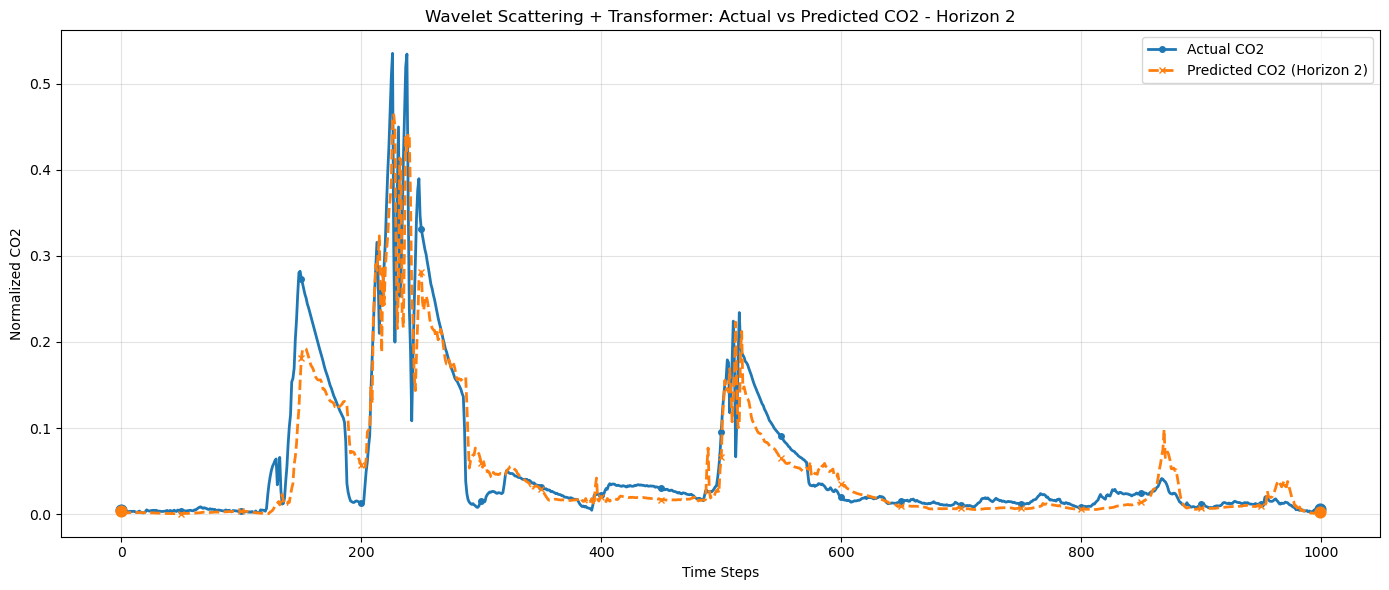

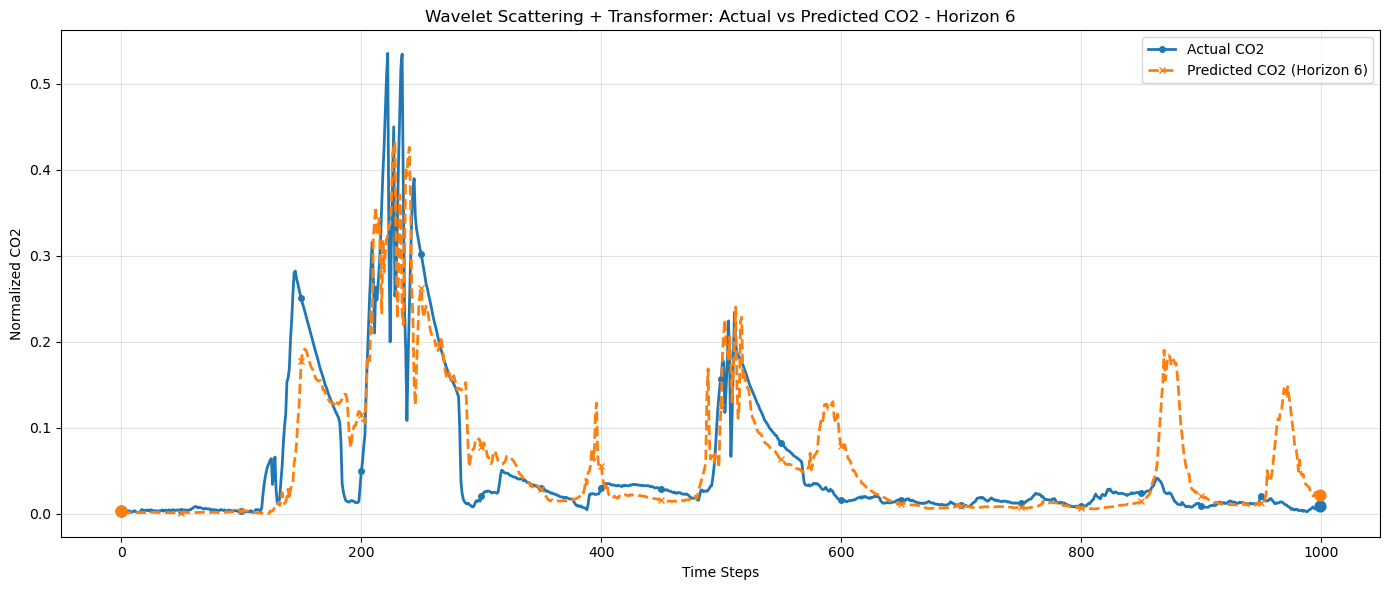

In [27]:
PLOT_SIZE = 1000

# Convert arrays to 2D so this works for OUTPUT_LENGTH = 1, 6, 12, 24, etc.
actual_2d = np.asarray(actual)
predictions_2d = np.asarray(predictions)

if actual_2d.ndim == 1:
    actual_2d = actual_2d.reshape(-1, 1)

if predictions_2d.ndim == 1:
    predictions_2d = predictions_2d.reshape(-1, 1)

horizon = predictions_2d.shape[1]

# The actual target signal is aligned to the selected prediction horizon.
horizons_to_plot = [2]

if horizon > 1:
    horizons_to_plot.append(horizon)

for horizon_to_compare in horizons_to_plot:

    # Create one separate graph for each horizon.
    plt.figure(figsize=(14, 6))

    # Plot only if this horizon exists in the model output.
    if horizon >= horizon_to_compare:

        horizon_index = horizon_to_compare - 1

        # Actual values
        actual_values = actual_2d[:, horizon_index]

        # Predicted values
        predicted_values = predictions_2d[:, horizon_index]

        plot_size = min(PLOT_SIZE, len(actual_values), len(predicted_values))
        time_steps = np.arange(plot_size)

        plt.plot(
            time_steps,
            actual_values[:plot_size],
            label=f"Actual {target_label}",
            linewidth=2,
            marker="o",
            markevery=50,
            markersize=4
        )

        plt.plot(
            time_steps,
            predicted_values[:plot_size],
            label=f"Predicted {target_label} (Horizon {horizon_to_compare})",
            linewidth=2,
            linestyle="--",
            marker="x",
            markevery=50,
            markersize=5
        )

        # Highlight the first and last plotted points.
        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [actual_values[:plot_size][0], actual_values[:plot_size][-1]],
            s=60,
            zorder=5
        )

        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [predicted_values[:plot_size][0], predicted_values[:plot_size][-1]],
            s=60,
            zorder=5
        )

        # Plot formatting
        plt.title(f"Wavelet Scattering + Transformer: Actual vs Predicted {target_label} - Horizon {horizon_to_compare}")
        plt.xlabel("Time Steps")
        plt.ylabel(f"Normalized {target_label}")
        plt.legend()
        plt.grid(True, alpha=0.35)

    else:

        # Plot formatting when the requested horizon is not available.
        plt.title(f"Horizon {horizon_to_compare} Not Available")
        plt.text(
            0.5,
            0.5,
            f"OUTPUT_LENGTH = {horizon}\nTrain with OUTPUT_LENGTH >= {horizon_to_compare}",
            ha="center",
            va="center",
            transform=plt.gca().transAxes,
            fontsize=12
        )
        plt.xlabel("Time Steps")
        plt.ylabel(f"Normalized {target_label}")
        plt.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()

## Training and Validation Loss Visualization

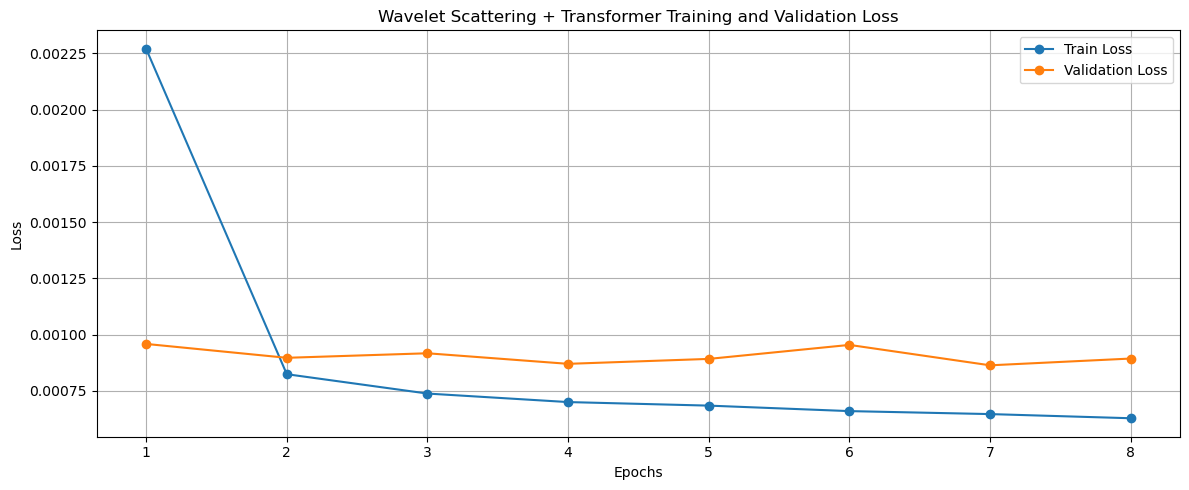

In [ ]:
plt.figure(figsize=(12, 5))

# Training loss
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Train Loss"
)

# Validation loss
plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

# Plot formatting
plt.title("Wavelet Scattering + Transformer Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "wavelet_h72_o12.pth")

print("Model saved successfully!")

Model saved successfully!


# Explainability Analysis

## Technique 1: Attention Weight Analysis

In [ ]:
print(model)

for name, module in model.named_modules():
    if isinstance(module, nn.MultiheadAttention):
        print("\nFound MultiheadAttention Layer:")
        print(name)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)

Found MultiheadAttention Layer:
transformer_e

### Step 1: Attention Weight Extraction Verification

In [ ]:
num_samples = 100

# Get first batch from test loader
X_batch, y_batch = next(iter(test_loader))

sample_batch = X_batch[:num_samples].to(device)

print("Sample shape:", sample_batch.shape)

with torch.no_grad():

    projected = model.input_projection(sample_batch)

    projected = model.positional_encoding(projected)

    attention_output, attention_weights = (
        model.transformer_encoder.layers[0].self_attn(
            projected,
            projected,
            projected,
            need_weights=True,
            average_attn_weights=False
        )
    )

print("Attention output shape:")
print(attention_output.shape)

print("\nAttention weights shape:")
print(attention_weights.shape)

Sample shape: torch.Size([64, 72, 12])
Attention output shape:
torch.Size([64, 72, 64])

Attention weights shape:
torch.Size([64, 4, 72, 72])


### Step 2: Attention Heatmap Visualization

Attention Matrix Shape: (72, 72)


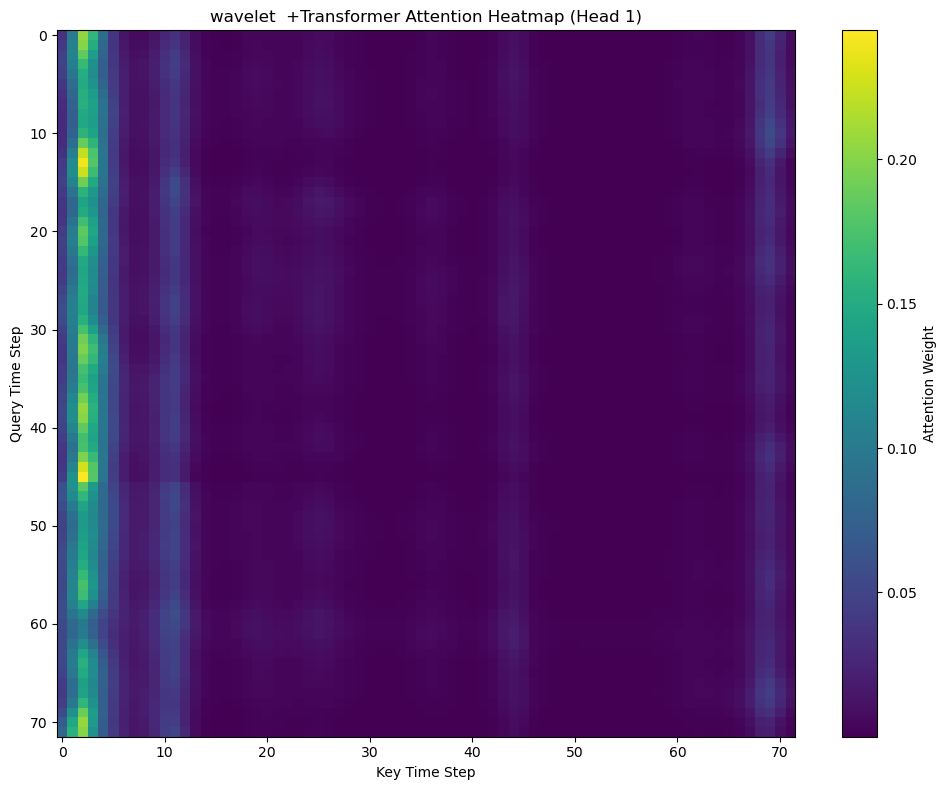

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select first sample
attention_matrix = (
    attention_weights[0, 0]  # Sample 0, Head 0
    .cpu()
    .numpy()
)

print("Attention Matrix Shape:", attention_matrix.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    attention_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "wavelet  +Transformer Attention Heatmap (Head 1)"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

### Step 3: Average Multi-Head Attention Analysis

Average Attention Shape: (72, 72)


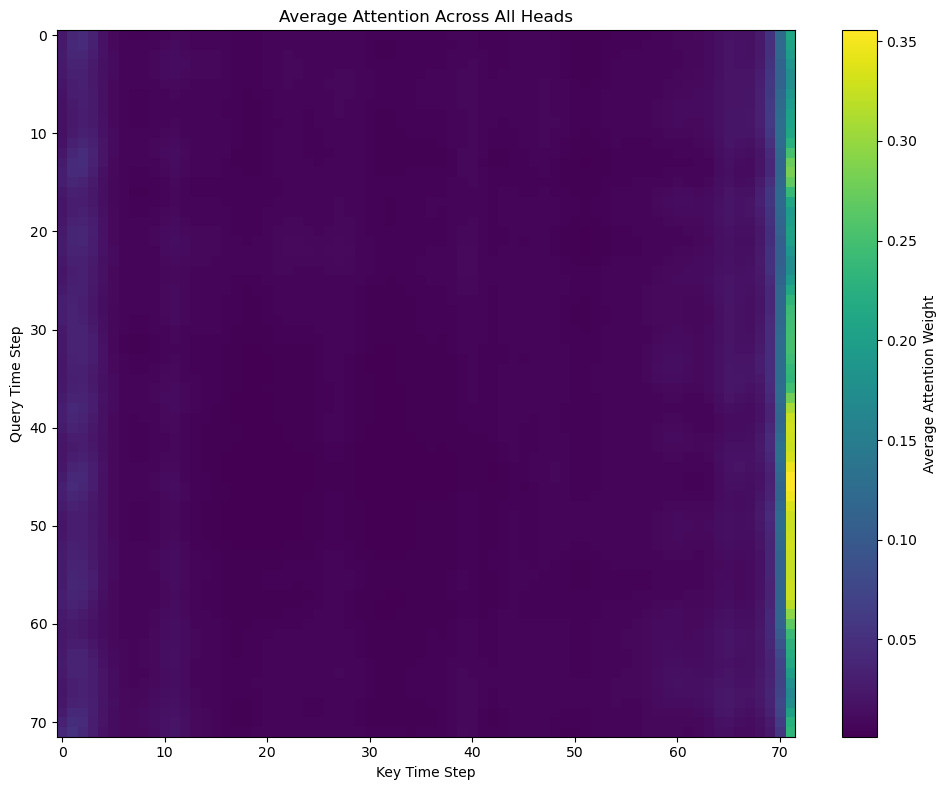

In [ ]:
# Average across all 4 heads
avg_attention = (
    attention_weights
    .mean(dim=(0,1))
    .cpu()
    .numpy()
)

print("Average Attention Shape:", avg_attention.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    avg_attention,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Attention Weight")

plt.title(
    "Average Attention Across All Heads"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

## Step 4: Most Important Historical Timesteps

Top 10 Most Important Timesteps
Rank 1: Timestep 71 (Importance = 0.2526)
Rank 2: Timestep 70 (Importance = 0.1130)
Rank 3: Timestep 69 (Importance = 0.0438)
Rank 4: Timestep 2 (Importance = 0.0347)
Rank 5: Timestep 1 (Importance = 0.0342)
Rank 6: Timestep 3 (Importance = 0.0267)
Rank 7: Timestep 0 (Importance = 0.0247)
Rank 8: Timestep 68 (Importance = 0.0240)
Rank 9: Timestep 65 (Importance = 0.0185)
Rank 10: Timestep 4 (Importance = 0.0174)


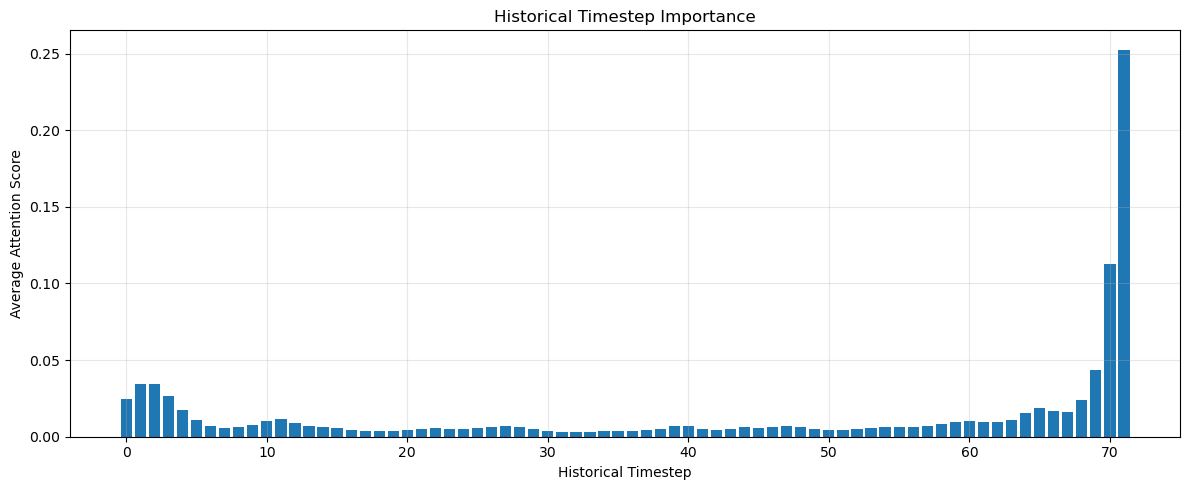

In [ ]:
# Average attention over all query positions
importance_scores = avg_attention.mean(axis=0)

# Top 10 most important timesteps
top_k = 10

top_indices = np.argsort(importance_scores)[-top_k:][::-1]

print("Top 10 Most Important Timesteps")

for rank, idx in enumerate(top_indices, start=1):
    print(
        f"Rank {rank}: "
        f"Timestep {idx} "
        f"(Importance = {importance_scores[idx]:.4f})"
    )

# Visualization
plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.title(
    "Historical Timestep Importance"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Average Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Attention Head Comparison

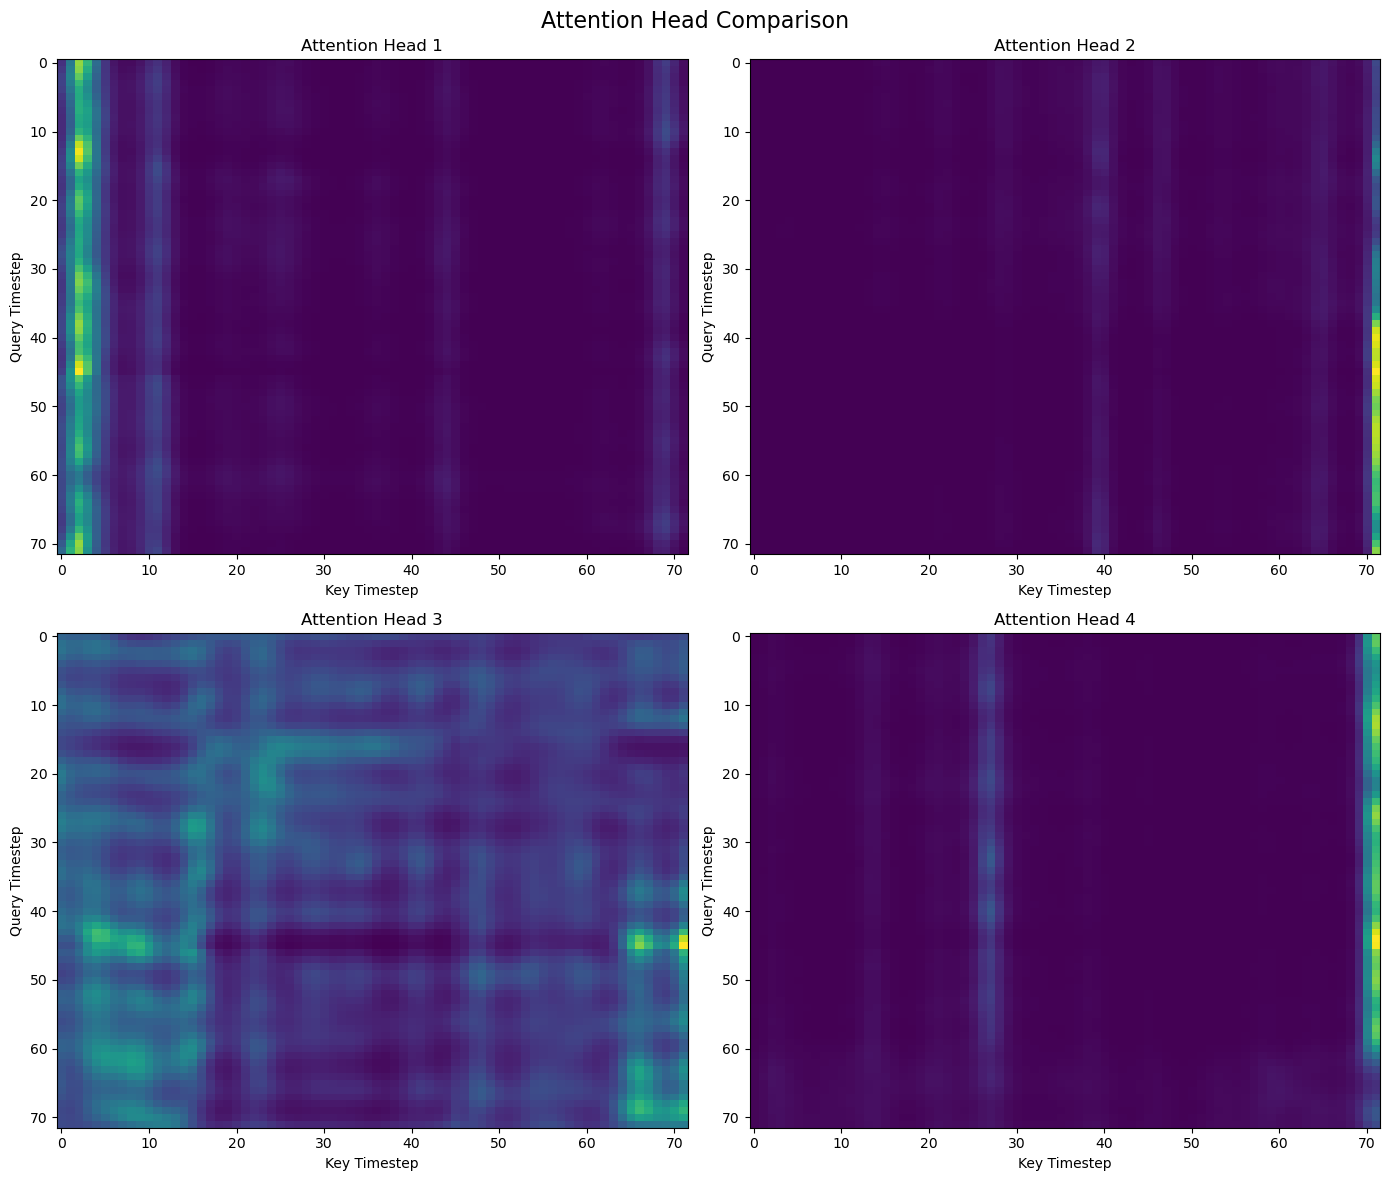

In [ ]:
import matplotlib.pyplot as plt

sample_attention = attention_weights[0]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

for head_idx, ax in enumerate(axes.flat):

    head_attention = (
        sample_attention[head_idx]
        .cpu()
        .numpy()
    )

    im = ax.imshow(
        head_attention,
        aspect="auto",
        cmap="viridis"
    )

    ax.set_title(
        f"Attention Head {head_idx + 1}"
    )

    ax.set_xlabel("Key Timestep")
    ax.set_ylabel("Query Timestep")

plt.suptitle(
    "Attention Head Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Technique 2: Feature Ablation Analysis


## Step 1: Baseline Performance

In [ ]:
baseline_rmse = rmse
baseline_mae = mae

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)

Baseline RMSE: 0.03414470210434679
Baseline MAE : 0.01670810580253601


# Step 2: Single Feature Ablation Verification

In [ ]:
feature_to_test = "scd41_co2"

feature_idx = feature_columns.index(
    feature_to_test
)

predictions_ablation = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.clone()

        # Remove selected feature
        X_batch[:, :, feature_idx] = 0

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions_ablation.extend(
            outputs.cpu().numpy()
        )

predictions_ablation = np.array(
    predictions_ablation
)

rmse_ablation = np.sqrt(
    mean_squared_error(
        actual,
        predictions_ablation
    )
)

mae_ablation = mean_absolute_error(
    actual,
    predictions_ablation
)

print("\nFeature Removed:", feature_to_test)

print("Baseline RMSE :", baseline_rmse)
print("New RMSE      :", rmse_ablation)

print(
    "RMSE Increase :",
    rmse_ablation - baseline_rmse
)

print("\nBaseline MAE :", baseline_mae)
print("New MAE      :", mae_ablation)


Feature Removed: scd41_co2
Baseline RMSE : 0.03414470210434679
New RMSE      : 0.09519344480621011
RMSE Increase : 0.06104874270186333

Baseline MAE : 0.01670810580253601
New MAE      : 0.05405290797352791


## Step 3: Multi-Feature Ablation Analysis

In [ ]:
ablation_features = [
    "scd41_co2",
    "scd41_temperature",
    "scd41_humidity",
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance"
]

In [ ]:
ablation_results = []

baseline_rmse = rmse
baseline_mae = mae

model.eval()

for feature_to_test in ablation_features:

    print(f"\nTesting Feature: {feature_to_test}")

    feature_idx = feature_columns.index(
        feature_to_test
    )

    predictions_ablation = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.clone()

            # Remove selected feature
            X_batch[:, :, feature_idx] = 0

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            predictions_ablation.extend(
                outputs.cpu().numpy()
            )

    predictions_ablation = np.array(
        predictions_ablation
    )

    rmse_ablation = np.sqrt(
        mean_squared_error(
            actual,
            predictions_ablation
        )
    )

    mae_ablation = mean_absolute_error(
        actual,
        predictions_ablation
    )

    rmse_increase = (
        rmse_ablation - baseline_rmse
    )

    mae_increase = (
        mae_ablation - baseline_mae
    )

    ablation_results.append([
        feature_to_test,
        rmse_ablation,
        mae_ablation,
        rmse_increase,
        mae_increase
    ])

    print(
        f"RMSE Increase: {rmse_increase:.6f}"
    )

# Convert to DataFrame
ablation_df = pd.DataFrame(
    ablation_results,
    columns=[
        "Feature",
        "RMSE",
        "MAE",
        "RMSE Increase",
        "MAE Increase"
    ]
)

# Sort by importance
ablation_df = (
    ablation_df
    .sort_values(
        by="RMSE Increase",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
ablation_df.index += 1

print("\nFeature Importance Ranking\n")
print(ablation_df)

NameError: name 'rmse' is not defined

## step 4: Feature Importance Visualization

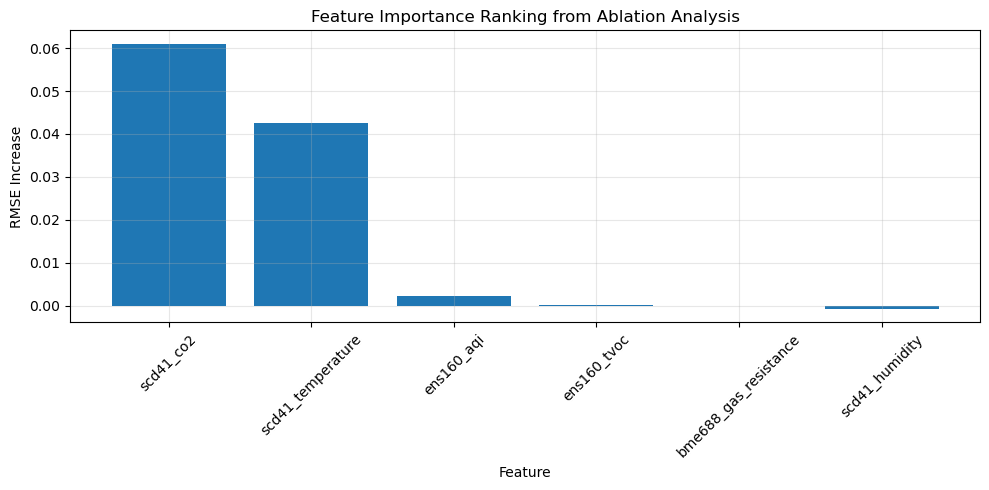

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    ablation_df["Feature"],
    ablation_df["RMSE Increase"]
)

plt.title(
    "Feature Importance Ranking from Ablation Analysis"
)

plt.xlabel("Feature")
plt.ylabel("RMSE Increase")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Uncertainty Quantification

## Technique 1: Monte Carlo Dropout

## Step 1:Dropout Layer Verification

In [ ]:
print(model)

dropout_count = 0

for name, module in model.named_modules():

    if isinstance(module, nn.Dropout):

        dropout_count += 1

        print(
            f"Dropout Layer {dropout_count}:",
            name
        )

print(
    "\nTotal Dropout Layers:",
    dropout_count
)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)
Dropout Layer 1: transformer_encoder.layers.0.

## Step 2: Generate Monte Carlo Predictions

In [ ]:
# Get one sample from test set

X_batch, y_batch = next(iter(test_loader))

sample = X_batch[:1].to(device)

mc_predictions = []

# Keep dropout active
model.train()

with torch.no_grad():

    for i in range(10):

        prediction = model(sample)

        mc_predictions.append(
            prediction.cpu().numpy()
        )

mc_predictions = np.array(
    mc_predictions
)

print(
    "MC Prediction Shape:"
)

print(
    mc_predictions.shape
)

print(
    "\nFirst Prediction:"
)

print(
    mc_predictions[0]
)

print(
    "\nSecond Prediction:"
)

print(
    mc_predictions[1]
)

MC Prediction Shape:
(10, 1, 12)

First Prediction:
[[0.01112352 0.00576037 0.00381812 0.00122599 0.00117819 0.00206888
  0.00356707 0.00471323 0.00553447 0.00580846 0.00719329 0.01018759]]

Second Prediction:
[[0.01301011 0.00579645 0.00552059 0.00258584 0.00417364 0.00595317
  0.00677058 0.0070522  0.00738208 0.00589537 0.00796501 0.01067782]]


## Step 3: Compute Confidence Intervals

In [ ]:
# Mean forecast

mean_prediction = np.mean(
    mc_predictions,
    axis=0
)

# Forecast uncertainty

std_prediction = np.std(
    mc_predictions,
    axis=0
)

# 95% Confidence Interval

lower_bound = (
    mean_prediction
    - 1.96 * std_prediction
)

upper_bound = (
    mean_prediction
    + 1.96 * std_prediction
)

print("Mean Prediction:\n")
print(mean_prediction)

print("\nStandard Deviation:\n")
print(std_prediction)

print("\nLower Bound:\n")
print(lower_bound)

print("\nUpper Bound:\n")
print(upper_bound)

Mean Prediction:

[[0.01239877 0.00802425 0.00740788 0.00508077 0.00510811 0.00569337
  0.00668918 0.00734542 0.00782275 0.00679074 0.00791567 0.01084941]]

Standard Deviation:

[[0.00254498 0.00318541 0.00295348 0.0031936  0.00303987 0.00293134
  0.00296787 0.00235529 0.00269793 0.00257267 0.00290103 0.00284952]]

Lower Bound:

[[ 7.4106106e-03  1.7808522e-03  1.6190638e-03 -1.1786958e-03
  -8.5003534e-04 -5.2066054e-05  8.7216590e-04  2.7290448e-03
   2.5347983e-03  1.7483006e-03  2.2296524e-03  5.2643623e-03]]

Upper Bound:

[[0.01738694 0.01426765 0.0131967  0.01134023 0.01106625 0.0114388
  0.0125062  0.01196179 0.0131107  0.01183318 0.0136017  0.01643447]]


## Step 4: Visualize Uncertainty

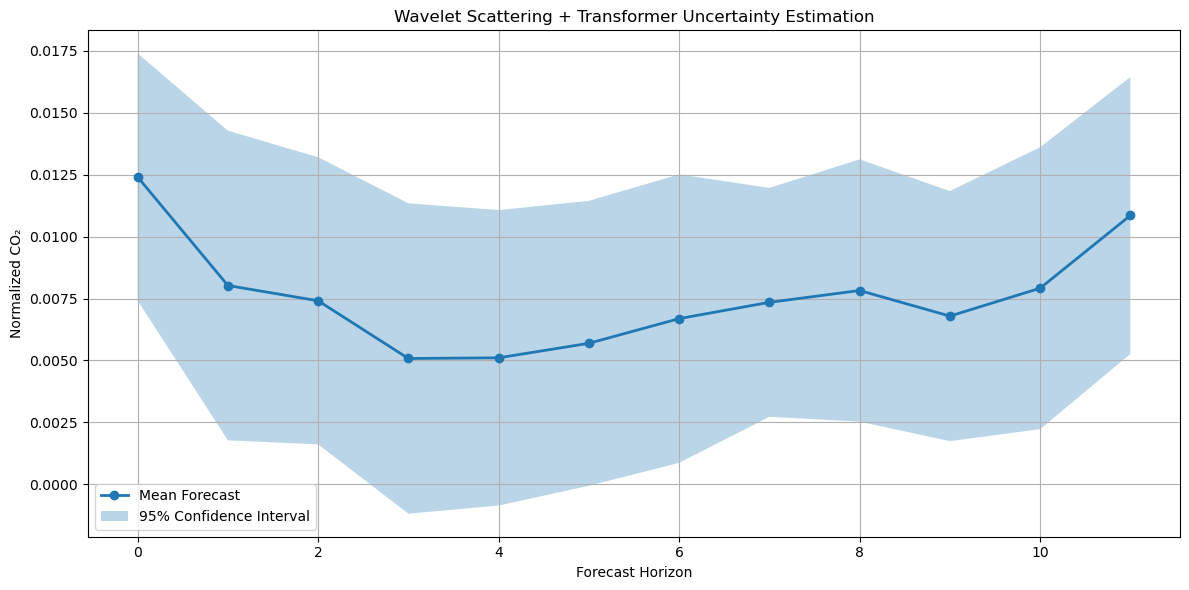

In [ ]:
plt.figure(figsize=(12,6))

time_steps = np.arange(
    mean_prediction.shape[1]
)

plt.plot(
    time_steps,
    mean_prediction[0],
    marker="o",
    linewidth=2,
    label="Mean Forecast"
)

plt.fill_between(
    time_steps,
    lower_bound[0],
    upper_bound[0],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(
    "Wavelet Scattering + Transformer Uncertainty Estimation"
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "Normalized CO₂"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## Uncertainty Summary Table

In [ ]:
uncertainty_df = pd.DataFrame({

    "Forecast Horizon": np.arange(
        1,
        OUTPUT_LENGTH + 1
    ),

    "Mean Prediction":
        mean_prediction[0],

    "Std Dev":
        std_prediction[0],

    "Lower Bound":
        lower_bound[0],

    "Upper Bound":
        upper_bound[0]
})

uncertainty_df

,Forecast Horizon,Mean Prediction,Std Dev,Lower Bound,Upper Bound
0,1,0.012399,0.002545,0.007411,0.017387
1,2,0.008024,0.003185,0.001781,0.014268
2,3,0.007408,0.002953,0.001619,0.013197
3,4,0.005081,0.003194,-0.001179,0.011340
4,5,0.005108,0.003040,-0.000850,0.011066
5,6,0.005693,0.002931,-0.000052,0.011439
6,7,0.006689,0.002968,0.000872,0.012506
7,8,0.007345,0.002355,0.002729,0.011962
8,9,0.007823,0.002698,0.002535,0.013111
9,10,0.006791,0.002573,0.001748,0.011833


## Technique 2: Forecast Horizon Error Analysis

## step 1: Compute Horizon RMSE

In [ ]:
horizon_rmse = []

for horizon in range(OUTPUT_LENGTH):

    rmse_h = np.sqrt(
        mean_squared_error(
            actual[:, horizon],
            predictions[:, horizon]
        )
    )

    horizon_rmse.append(
        rmse_h
    )

horizon_rmse

[np.float64(0.01848946498765255),
 np.float64(0.02268387845629122),
 np.float64(0.026524661835417376),
 np.float64(0.030700391612550955),
 np.float64(0.0337068342737359),
 np.float64(0.03521047820580322),
 np.float64(0.03603762576834313),
 np.float64(0.03706772876655144),
 np.float64(0.03836332082362805),
 np.float64(0.03974960385459184),
 np.float64(0.04106476655493471),
 np.float64(0.04124583624286039)]

## step 2: Create Table

In [ ]:
horizon_df = pd.DataFrame({

    "Forecast Horizon":
        np.arange(
            1,
            OUTPUT_LENGTH + 1
        ),

    "RMSE":
        horizon_rmse
})

horizon_df

,Forecast Horizon,RMSE
0,1,0.018489
1,2,0.022684
2,3,0.026525
3,4,0.030700
4,5,0.033707
5,6,0.035210
6,7,0.036038
7,8,0.037068
8,9,0.038363
9,10,0.039750


## step 3: Visualization

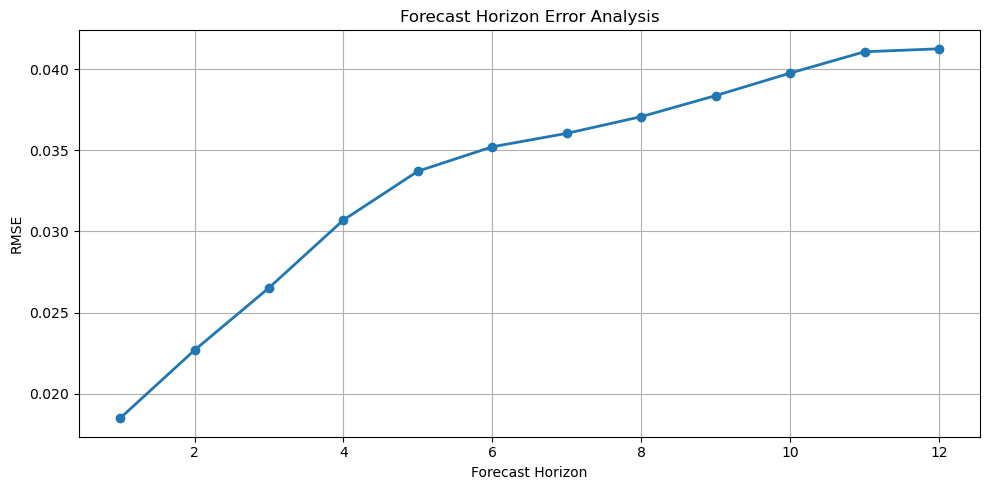

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    horizon_df["Forecast Horizon"],
    horizon_df["RMSE"],
    marker="o",
    linewidth=2
)

plt.title(
    "Forecast Horizon Error Analysis"
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "RMSE"
)

plt.grid(True)

plt.tight_layout()

plt.show()